# 1.2 Preprocessing — Full-Stack Test (510 planes)

Background removal (rolling ball) and PSF-centered Richardson-Lucy deconvolution are computed
in `1_1_preprocessing.ipynb`. This notebook **reads those saved full-stack outputs** and QCs
them against `zone_samples.csv`, which defines representative depth zones across the stack.

Two separate checks:
- **Data-integrity check** (Section 3): whole-plane mean at each `sample_plane` vs. the
  `sample_plane_intensity` recorded in `zone_samples.csv`, confirming the loaded raw stack
  matches the one the reference values were built from.
- **Signal QC** (Sections 5, 7): a **normalized foreground mean** per stage, reported as
  **mean ± SD across all planes in each zone's `z_start:z_end` range** (not a single plane).
  For every plane the foreground is isolated by Otsu thresholding (connexin signal), and each
  stage is scaled to its own 99.5th-percentile intensity so the three stages sit on a common,
  dimensionless scale.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage import io
from skimage.filters import threshold_otsu

BASE_DIR = Path.cwd().parent

## 0. Load zone samples

Adjust `zone_samples_path` below if your file lives somewhere else.

In [2]:
zone_samples_path = BASE_DIR / 'data' / 'zone_samples.csv'
zone_samples = pd.read_csv(zone_samples_path)
print(f"Loaded {len(zone_samples)} zones from {zone_samples_path}")
zone_samples


Loaded 9 zones from /home/rck292/Project/data/zone_samples.csv


,zone_number,zone_label,z_start,z_end,sample_plane,sample_plane_intensity
0,1,plateau,0,34,17,236.49
1,2,rising-1,34,101,67,515.66
2,3,rising-2,101,169,135,2222.98
3,4,rising-3,169,236,202,5335.92
4,5,rising-4,236,304,270,9162.24
5,6,rising-5,304,372,338,11514.37
6,7,falling-1,372,417,394,11384.69
7,8,falling-2,417,463,440,9689.39
8,9,falling-3,463,509,486,7286.28


## 1. Load the raw image stack

Used as the "before" reference for QC comparisons.

In [3]:
cnx_path = BASE_DIR / 'data' / 'raw' / 'corrected_images' / 'cnx43.tif'
cnx_img = io.imread(cnx_path)
print(f"Loaded stack: shape={cnx_img.shape}, dtype={cnx_img.dtype}")

# remove black border on top (matches convention in 1_1_preprocessing.ipynb)
cnx_img = cnx_img[:,15:, 3:]
print(f"After border crop: shape={cnx_img.shape}")

n_planes = cnx_img.shape[0]

out_of_range = zone_samples[~zone_samples['sample_plane'].between(0, n_planes - 1)]
if len(out_of_range):
    print("WARNING: sample planes out of range for this stack:")
    print(out_of_range)
else:
    print("All zone_samples.sample_plane values are within the stack range.")


Loaded stack: shape=(510, 2048, 1012), dtype=uint16
After border crop: shape=(510, 2033, 1009)
All zone_samples.sample_plane values are within the stack range.


## 2. QC helpers

In [4]:
def plot_zone_grid(stack, zone_df, title, cmap='gray', ncols=4, vmax_percentile=99.5):
    """One subplot per zone, showing that zone's sample_plane (representative image only)."""
    n = len(zone_df)
    ncols = min(ncols, n)
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        ax = axes[i // ncols, i % ncols]
        plane = int(row['sample_plane'])
        vmax = np.percentile(stack[plane], vmax_percentile)
        ax.imshow(stack[plane], cmap=cmap, vmax=vmax)
        ax.set_title(f"{row['zone_label']} (plane {plane})")
        ax.axis('off')
    for j in range(n, nrows * ncols):
        axes[j // ncols, j % ncols].axis('off')
    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def zone_intensity_table(stack, zone_df, column_name):
    """Whole-plane mean at each zone's sample_plane (used only for the data-integrity
    check against the recorded sample_plane_intensity)."""
    values = [stack[int(row['sample_plane'])].mean() for _, row in zone_df.iterrows()]
    return pd.DataFrame({
        'zone_number': zone_df['zone_number'].values,
        column_name: values,
    })


def robust_max(stack, pmax=99.5, subsample=20):
    """Robust maximum (pmax-th percentile) from a strided voxel subsample. Used to scale a
    stage to a dimensionless [0, 1] range so stages with different native units (uint16
    counts vs. float32 deconvolution output) become comparable."""
    flat = np.asarray(stack).ravel()[::subsample]
    hi = float(np.percentile(flat, pmax))
    return hi if hi > 0 else 1.0


def foreground_mean(plane):
    """Mean intensity over the Otsu-thresholded foreground of a single plane. Isolates the
    connexin signal from empty/background pixels; a whole-plane mean is dominated by
    background, especially after rolling-ball subtraction zeroes most of the field."""
    p = np.asarray(plane, dtype=np.float32)
    finite = p[np.isfinite(p)]
    if finite.size == 0 or np.ptp(finite) == 0:
        return np.nan
    thr = threshold_otsu(finite)
    fg = p >= thr
    if not fg.any():
        return np.nan
    return float(p[fg].mean())


def zone_foreground_stats(stack, zone_df, mean_col, sd_col, norm):
    """Normalized foreground mean aggregated over every plane in each zone's z-range.

    For each zone, foreground_mean is computed on every plane in [z_start, z_end) (half-open,
    so the shared boundary planes between contiguous zones are not double-counted), each plane
    divided by `norm`. Returns per-zone mean and sample SD of those per-plane values, so the
    metric reflects the whole zone rather than one representative plane."""
    means, sds = [], []
    n_planes = stack.shape[0]
    for _, row in zone_df.iterrows():
        z0 = int(row['z_start'])
        z1 = min(int(row['z_end']), n_planes)
        vals = []
        for z in range(z0, z1):
            fm = foreground_mean(np.asarray(stack[z], dtype=np.float32) / norm)
            if not np.isnan(fm):
                vals.append(fm)
        vals = np.asarray(vals)
        means.append(vals.mean() if vals.size else np.nan)
        sds.append(vals.std(ddof=1) if vals.size > 1 else np.nan)
    return pd.DataFrame({
        'zone_number': zone_df['zone_number'].values,
        mean_col: means,
        sd_col: sds,
    })


def format_mean_sd(mean, sd):
    """Render 'mean ± SD' for a thesis-ready table; falls back gracefully on NaNs."""
    if np.isnan(mean):
        return "n/a"
    if np.isnan(sd):
        return f"{mean:.3f}"
    return f"{mean:.3f} ± {sd:.3f}"

## 3. Raw-stack QC (data-integrity check)

Whole-plane mean at each `sample_plane` vs. the recorded `sample_plane_intensity`. This is a
data-integrity check — a small, consistent offset is expected if the 15-row border crop here
was not applied when the reference values were originally recorded.

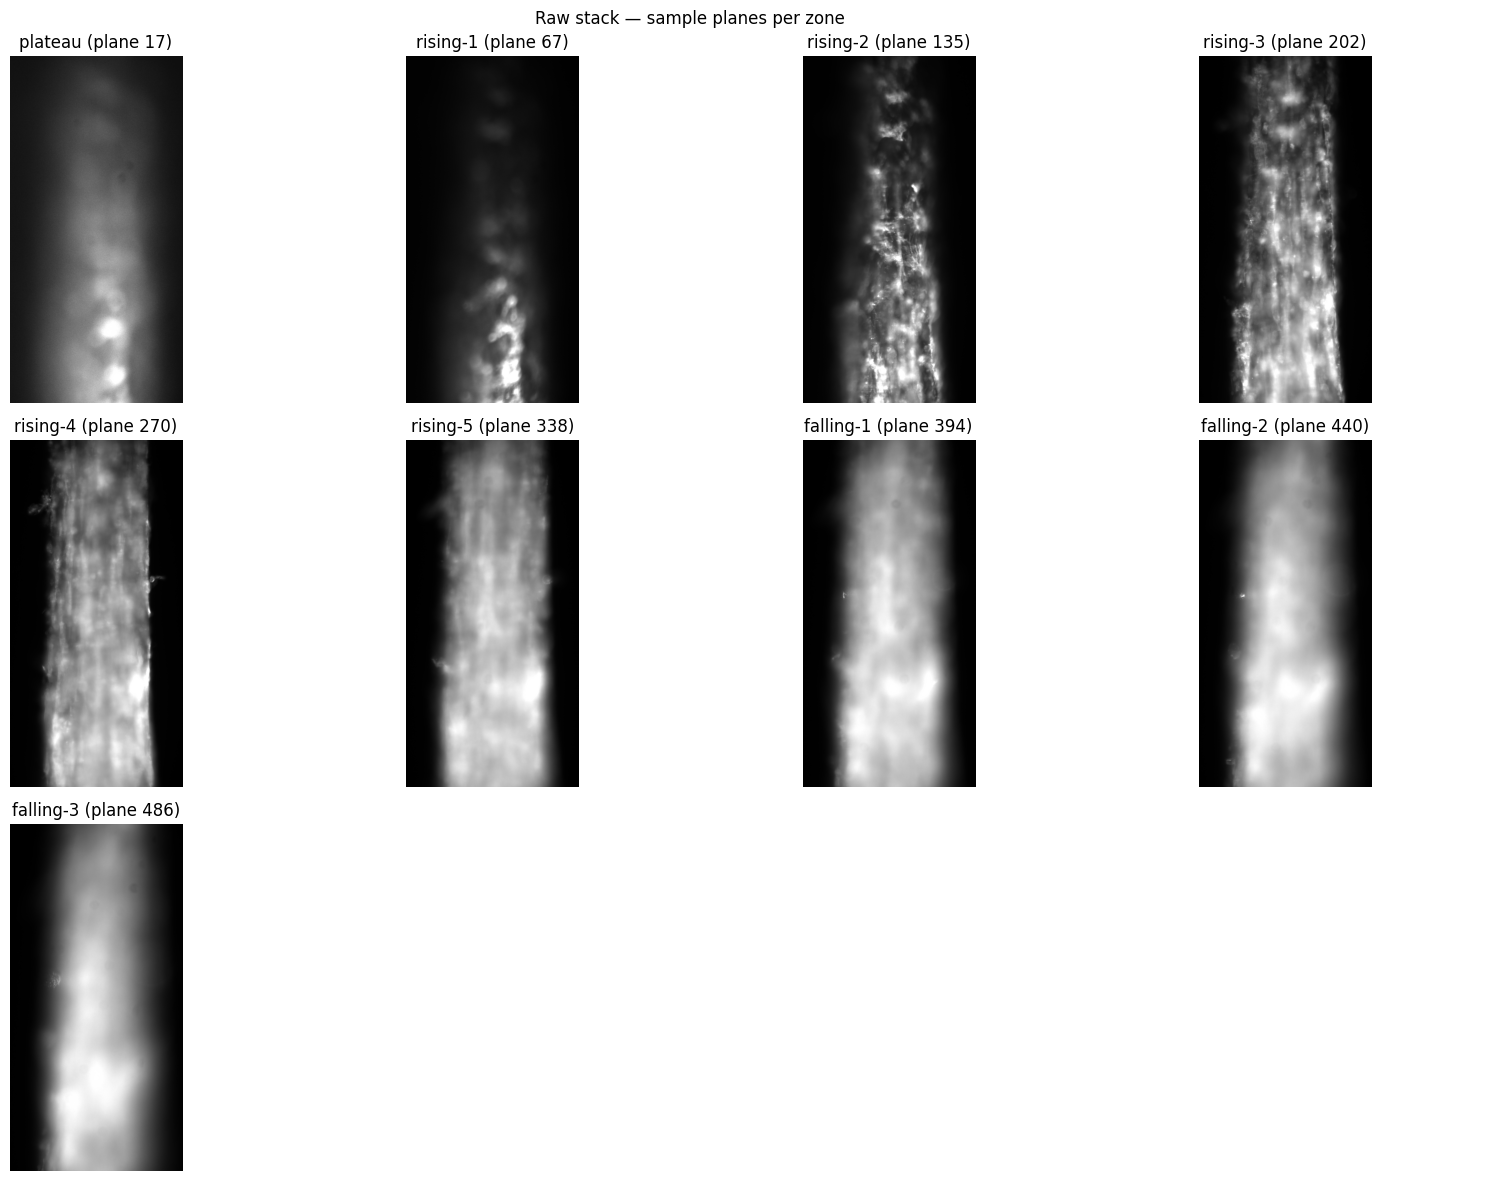

Recorded vs. computed intensity at each zone's sample plane (raw stack):


,zone_number,zone_label,sample_plane,sample_plane_intensity,computed_intensity_raw,diff,pct_diff
0,1,plateau,17,236.49,238.939115,2.449115,1.035610
1,2,rising-1,67,515.66,521.012069,5.352069,1.037907
2,3,rising-2,135,2222.98,2246.041705,23.061705,1.037423
3,4,rising-3,202,5335.92,5391.268112,55.348112,1.037274
4,5,rising-4,270,9162.24,9257.279250,95.039250,1.037293
5,6,rising-5,338,11514.37,11633.816317,119.446317,1.037367
6,7,falling-1,394,11384.69,11502.784659,118.094659,1.037311
7,8,falling-2,440,9689.39,9789.899075,100.509075,1.037311
8,9,falling-3,486,7286.28,7361.866701,75.586701,1.037384


In [5]:
plot_zone_grid(cnx_img, zone_samples, title="Raw stack — sample planes per zone")

raw_intensity = zone_intensity_table(cnx_img, zone_samples, 'computed_intensity_raw')
raw_comparison = zone_samples[['zone_number', 'zone_label', 'sample_plane', 'sample_plane_intensity']].merge(
    raw_intensity, on='zone_number'
)
raw_comparison['diff'] = raw_comparison['computed_intensity_raw'] - raw_comparison['sample_plane_intensity']
raw_comparison['pct_diff'] = 100 * raw_comparison['diff'] / raw_comparison['sample_plane_intensity']
print("Recorded vs. computed intensity at each zone's sample plane (raw stack):")
raw_comparison


## 4. Load background-removed image

Loads the rolling-ball background-subtracted stack saved by `1_1_preprocessing.ipynb`.
Path is relative to the `notebooks/` working directory, matching how it was saved.

In [6]:
bg_removed_path = BASE_DIR / 'data' / 'preprocessed' / 'background_removed_img.tiff'
background_removed = io.imread(bg_removed_path)
print(f"Loaded background-removed stack: shape={background_removed.shape}, dtype={background_removed.dtype}")
print(f"  from {bg_removed_path.resolve()}")

if background_removed.shape != cnx_img.shape:
    print(f"WARNING: shape mismatch vs. raw stack {cnx_img.shape}")

Loaded background-removed stack: shape=(510, 2033, 1009), dtype=uint16
  from /home/rck292/Project/data/preprocessed/background_removed_img.tiff


## 5. QC of background removal

Normalized foreground (connexin-signal) mean, raw vs. background-removed, as **mean ± SD over
each zone's `z_start:z_end` plane range**. The image grid above still shows the single
representative `sample_plane` per zone.

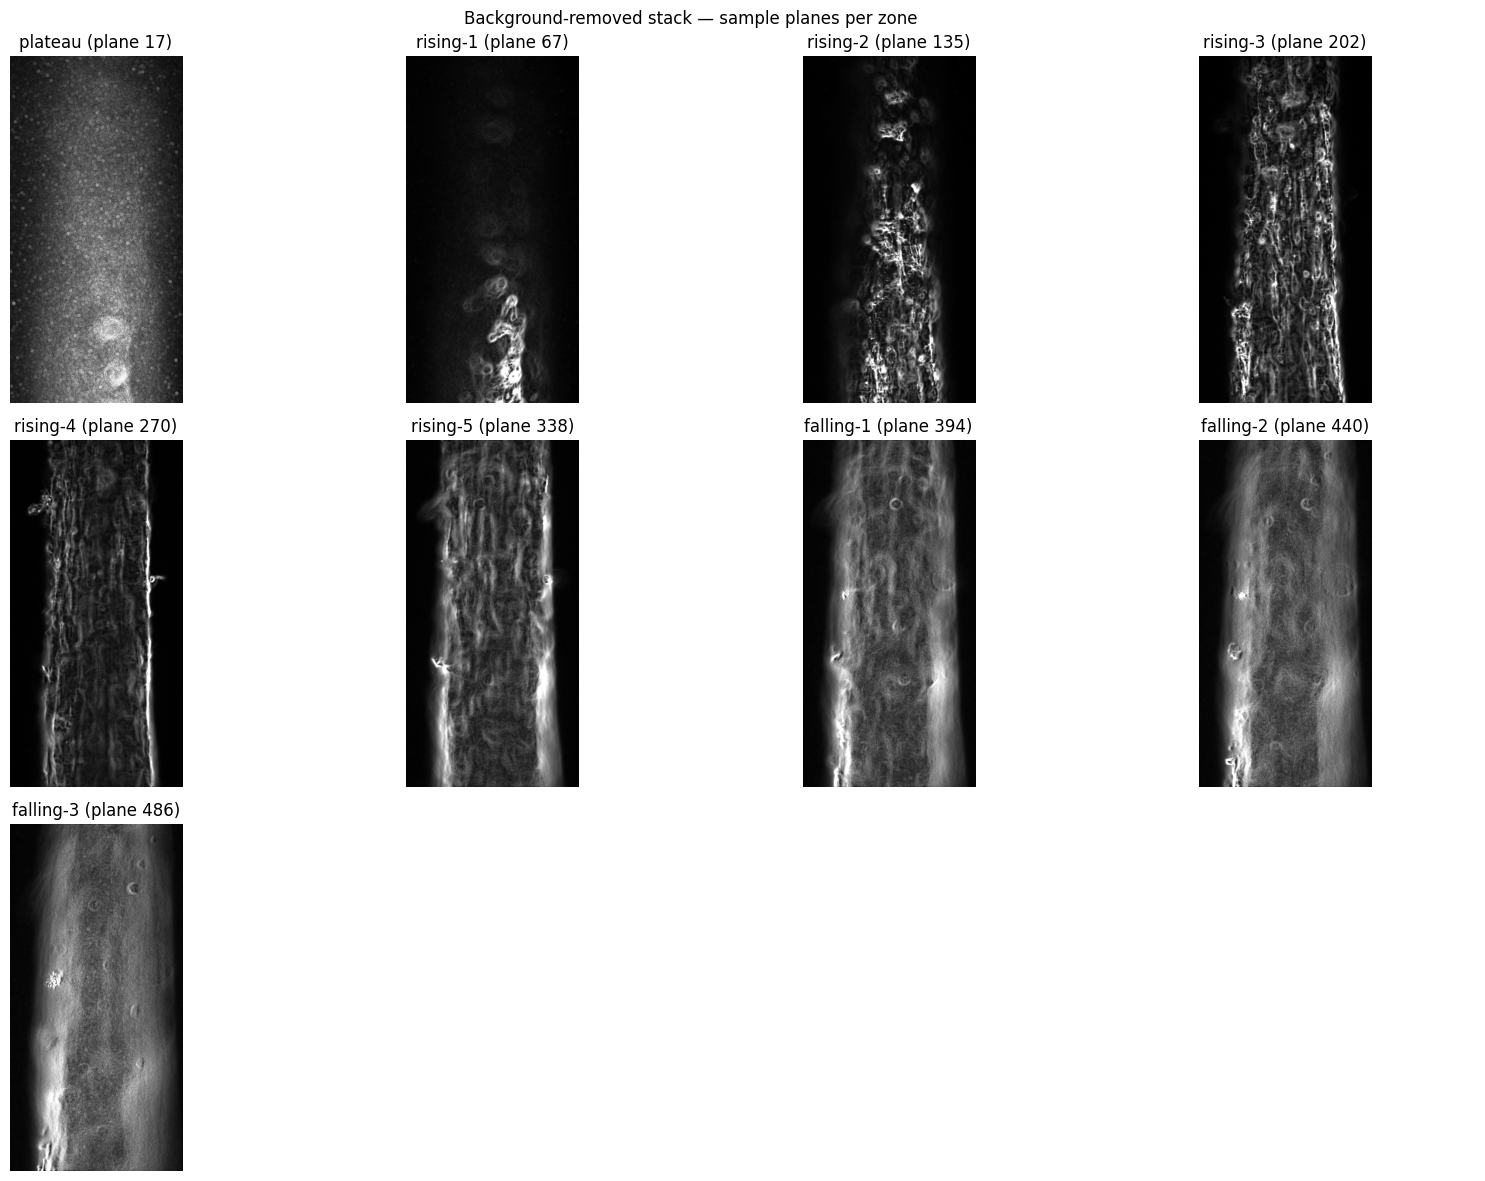

Normalized foreground mean, raw vs. background-removed (mean ± SD over each zone's z-range):


,zone_label,z_range,raw (mean ± SD),bg_removed (mean ± SD)
0,plateau,0:34,0.016 ± 0.003,0.017 ± 0.007
1,rising-1,34:101,0.084 ± 0.040,0.204 ± 0.147
2,rising-2,101:169,0.231 ± 0.057,0.486 ± 0.079
3,rising-3,169:236,0.423 ± 0.055,0.571 ± 0.016
4,rising-4,236:304,0.611 ± 0.052,0.710 ± 0.089
5,rising-5,304:372,0.743 ± 0.020,0.386 ± 0.057
6,falling-1,372:417,0.737 ± 0.021,0.266 ± 0.021
7,falling-2,417:463,0.636 ± 0.036,0.209 ± 0.010
8,falling-3,463:509,0.497 ± 0.044,0.170 ± 0.010


In [7]:
plot_zone_grid(background_removed, zone_samples, title="Background-removed stack — sample planes per zone")

raw_norm = robust_max(cnx_img)
bg_norm = robust_max(background_removed)
stats_raw = zone_foreground_stats(cnx_img, zone_samples, 'fg_mean_raw', 'fg_sd_raw', norm=raw_norm)
stats_bg = zone_foreground_stats(background_removed, zone_samples, 'fg_mean_bg_removed', 'fg_sd_bg_removed', norm=bg_norm)

bg_stats = (
    zone_samples[['zone_number', 'zone_label', 'z_start', 'z_end']]
    .merge(stats_raw, on='zone_number')
    .merge(stats_bg, on='zone_number')
)
bg_display = pd.DataFrame({
    'zone_label': bg_stats['zone_label'],
    'z_range': bg_stats['z_start'].astype(str) + ':' + bg_stats['z_end'].astype(str),
    'raw (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(bg_stats['fg_mean_raw'], bg_stats['fg_sd_raw'])],
    'bg_removed (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(bg_stats['fg_mean_bg_removed'], bg_stats['fg_sd_bg_removed'])],
})
print("Normalized foreground mean, raw vs. background-removed (mean ± SD over each zone's z-range):")
bg_display

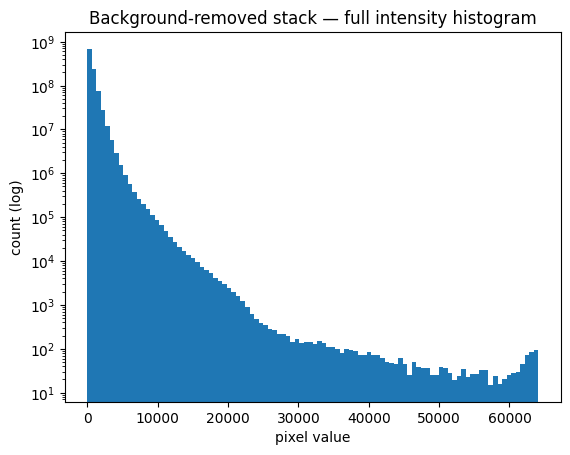

min=0, max=64068


In [8]:
plt.hist(background_removed.ravel(), bins=100)
plt.yscale('log')
plt.xlabel('pixel value')
plt.ylabel('count (log)')
plt.title('Background-removed stack — full intensity histogram')
plt.show()
print(f"min={background_removed.min()}, max={background_removed.max()}")


## 6. Load deconvolved image

Loads the PSF-centered Richardson-Lucy deconvolution output saved by
`1_1_preprocessing.ipynb`.

In [9]:
deconvolved_path = BASE_DIR / 'data' / 'preprocessed' / 'background_removed_and_deconvolved_img.tiff'
deconvolved = io.imread(deconvolved_path)
print(f"Loaded deconvolved stack: shape={deconvolved.shape}, dtype={deconvolved.dtype}")
print(f"  from {deconvolved_path.resolve()}")

if deconvolved.shape != cnx_img.shape:
    print(f"WARNING: shape mismatch vs. raw stack {cnx_img.shape}")

Loaded deconvolved stack: shape=(510, 2033, 1009), dtype=float32
  from /home/rck292/Project/data/preprocessed/background_removed_and_deconvolved_img.tiff


## 7. Final QC — raw vs. background-removed vs. deconvolved

Normalized foreground mean per stage, reported as **mean ± SD over each zone's `z_start:z_end`
plane range** so all three stages sit on the common dimensionless scale. (This aggregates every
plane in the stack and may take up to ~1 min.)

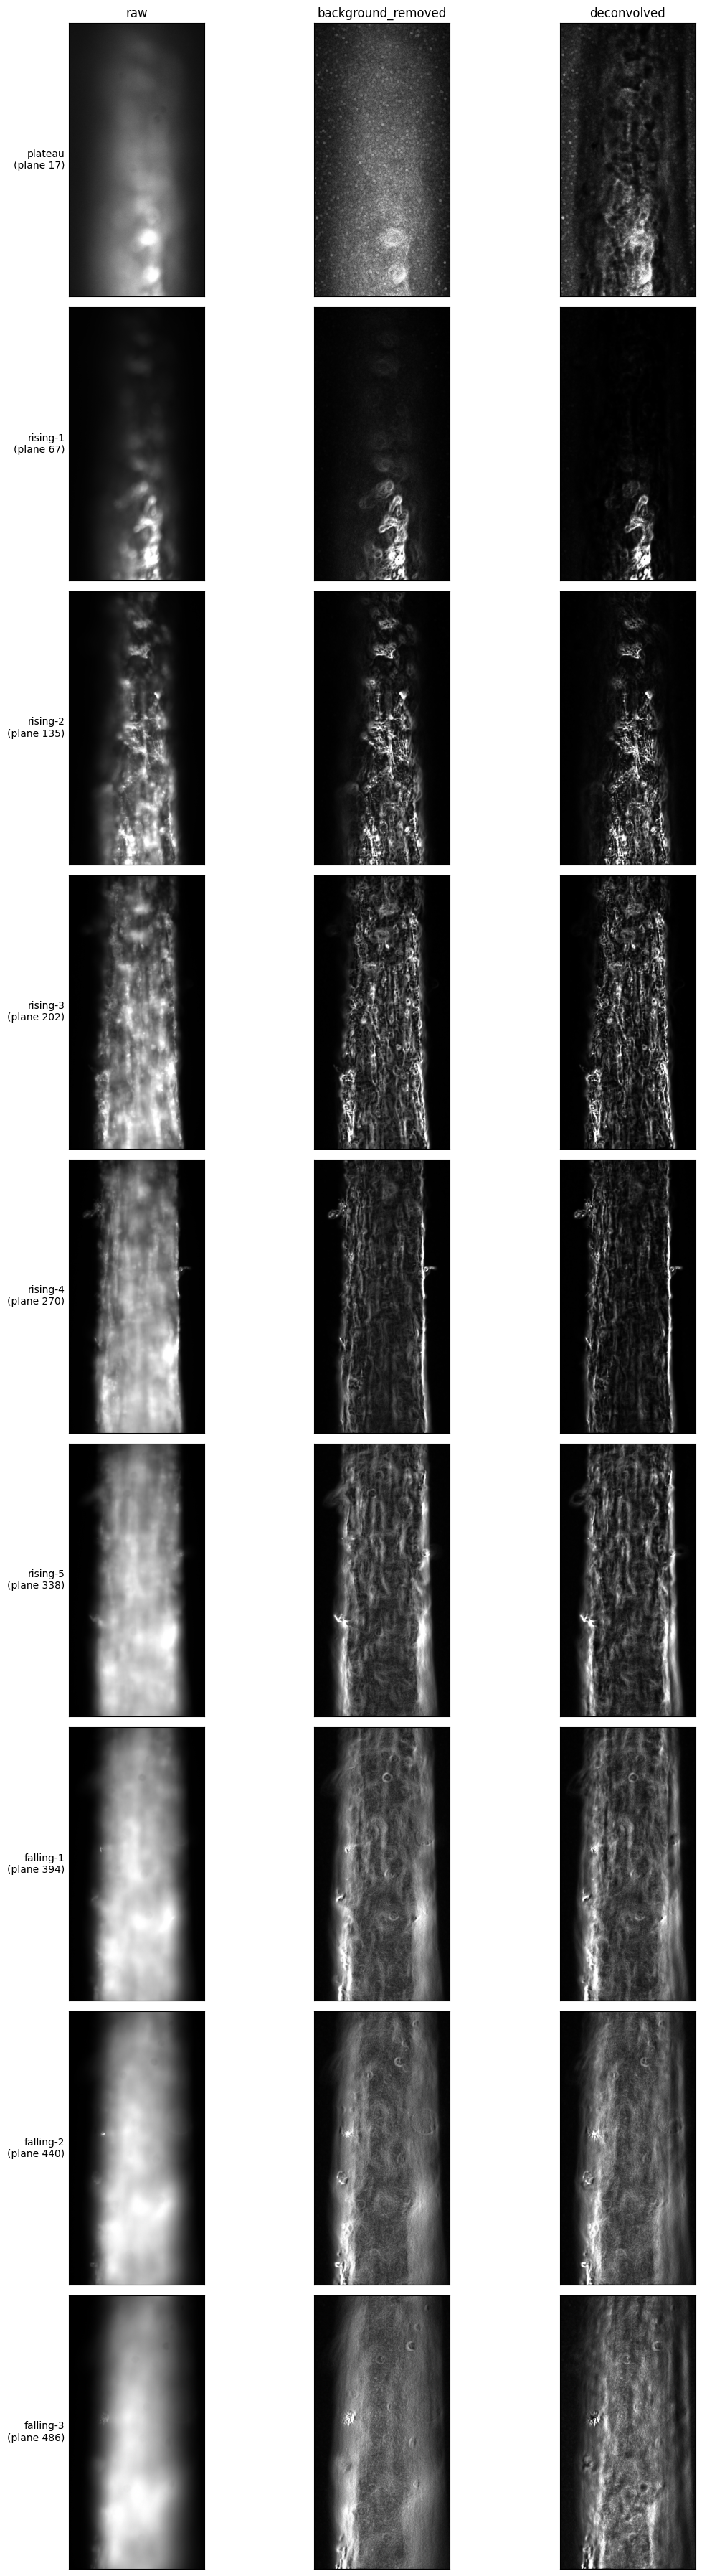

In [10]:
def plot_zone_stage_grid(stages, zone_df, cmap='gray', vmax_percentile=99.5):
    """Grid of (zone rows) x (pipeline stage columns) at each zone's sample_plane."""
    n_zones = len(zone_df)
    n_stages = len(stages)
    fig, axes = plt.subplots(n_zones, n_stages, figsize=(4 * n_stages, 4 * n_zones), squeeze=False)
    for i, (_, row) in enumerate(zone_df.iterrows()):
        plane = int(row['sample_plane'])
        for j, (stage_name, stage_stack) in enumerate(stages.items()):
            ax = axes[i, j]
            vmax = np.percentile(stage_stack[plane], vmax_percentile)
            ax.imshow(stage_stack[plane], cmap=cmap, vmax=vmax)
            if i == 0:
                ax.set_title(stage_name)
            if j == 0:
                ax.set_ylabel(f"{row['zone_label']}\n(plane {plane})", rotation=0, ha='right', va='center')
            ax.set_xticks([])
            ax.set_yticks([])
    plt.tight_layout()
    plt.show()

stages = {
    'raw': cnx_img,
    'background_removed': background_removed,
    'deconvolved': deconvolved,
}
plot_zone_stage_grid(stages, zone_samples)


In [11]:
raw_norm = robust_max(cnx_img)
bg_norm = robust_max(background_removed)
deconv_norm = robust_max(deconvolved)
print("Per-stage normalization factors (99.5th-percentile intensity):")
print(f"  raw={raw_norm:.1f}, background_removed={bg_norm:.1f}, deconvolved={deconv_norm:.4f}")

stats_raw = zone_foreground_stats(cnx_img, zone_samples, 'fg_mean_raw', 'fg_sd_raw', norm=raw_norm)
stats_bg = zone_foreground_stats(background_removed, zone_samples, 'fg_mean_bg_removed', 'fg_sd_bg_removed', norm=bg_norm)
stats_dc = zone_foreground_stats(deconvolved, zone_samples, 'fg_mean_deconvolved', 'fg_sd_deconvolved', norm=deconv_norm)

final_stats = zone_samples[['zone_number', 'zone_label', 'z_start', 'z_end']].copy()
for t in (stats_raw, stats_bg, stats_dc):
    final_stats = final_stats.merge(t, on='zone_number')

# thesis-ready 'mean ± SD' display; numeric columns remain in `final_stats` for further use
final_display = pd.DataFrame({
    'zone_label': final_stats['zone_label'],
    'z_range': final_stats['z_start'].astype(str) + ':' + final_stats['z_end'].astype(str),
    'raw (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(final_stats['fg_mean_raw'], final_stats['fg_sd_raw'])],
    'bg_removed (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(final_stats['fg_mean_bg_removed'], final_stats['fg_sd_bg_removed'])],
    'deconvolved (mean ± SD)': [format_mean_sd(m, s) for m, s in zip(final_stats['fg_mean_deconvolved'], final_stats['fg_sd_deconvolved'])],
})
print()
print("Normalized foreground mean per stage, mean ± SD over each zone's z-range")
print("(dimensionless, fraction of each stage's 99.5th-percentile intensity; comparable across stages/zones):")
final_display

Per-stage normalization factors (99.5th-percentile intensity):
  raw=26769.0, background_removed=4298.0, deconvolved=5837.4258

Normalized foreground mean per stage, mean ± SD over each zone's z-range
(dimensionless, fraction of each stage's 99.5th-percentile intensity; comparable across stages/zones):


,zone_label,z_range,raw (mean ± SD),bg_removed (mean ± SD),deconvolved (mean ± SD)
0,plateau,0:34,0.016 ± 0.003,0.017 ± 0.007,0.007 ± 0.003
1,rising-1,34:101,0.084 ± 0.040,0.204 ± 0.147,0.189 ± 0.178
2,rising-2,101:169,0.231 ± 0.057,0.486 ± 0.079,0.587 ± 0.072
3,rising-3,169:236,0.423 ± 0.055,0.571 ± 0.016,0.665 ± 0.042
4,rising-4,236:304,0.611 ± 0.052,0.710 ± 0.089,1.000 ± 0.265
5,rising-5,304:372,0.743 ± 0.020,0.386 ± 0.057,0.312 ± 0.053
6,falling-1,372:417,0.737 ± 0.021,0.266 ± 0.021,0.242 ± 0.020
7,falling-2,417:463,0.636 ± 0.036,0.209 ± 0.010,0.176 ± 0.049
8,falling-3,463:509,0.497 ± 0.044,0.170 ± 0.010,0.058 ± 0.015


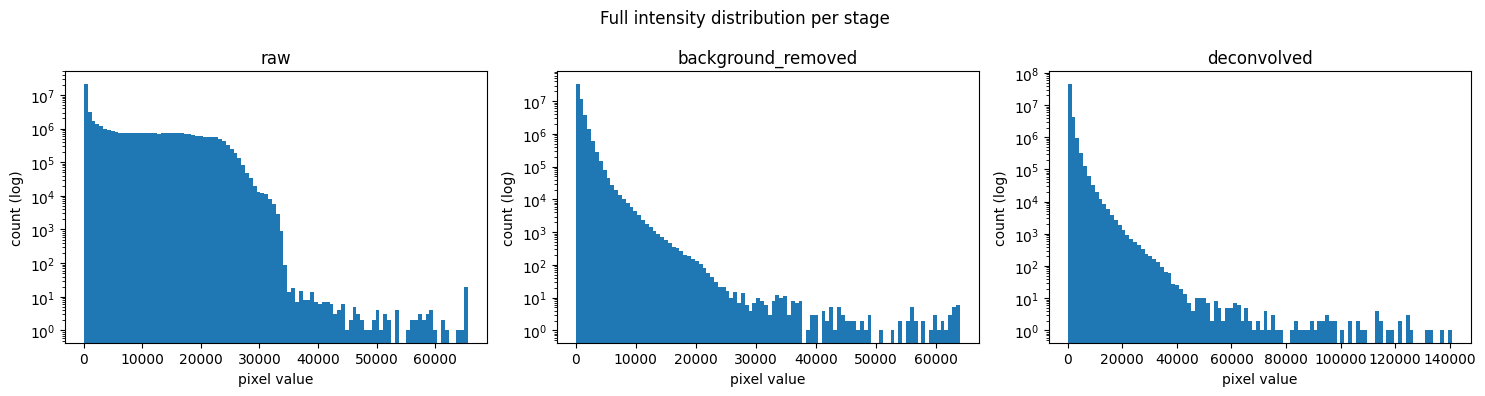

In [12]:
# Full intensity distribution per stage (subsampled for speed)
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, stack) in zip(
    axes,
    [('raw', cnx_img), ('background_removed', background_removed), ('deconvolved', deconvolved)],
):
    ax.hist(stack.ravel()[::20], bins=100)
    ax.set_yscale('log')
    ax.set_xlabel('pixel value')
    ax.set_ylabel('count (log)')
    ax.set_title(name)
fig.suptitle('Full intensity distribution per stage')
plt.tight_layout()
plt.show()

## 8. Compare SNRs

In [15]:
import numpy as np
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu

def compute_snr(plane, signal_percentile=99, background_percentile=50):
    """SNR = mean(signal) / std(background) for one image plane.

    Everything is derived automatically:
      - tissue   : the imaged column, separated from black crop padding (Otsu)
      - signal   : the brightest tissue pixels (top 1%)
      - background: the darker tissue pixels (bottom half) = noise floor
    """
    plane = np.asarray(plane, dtype=np.float64)   # avoid uint16 wraparound

    # 1. Tissue vs black padding: smooth, then Otsu-threshold the column shape.
    smoothed = gaussian_filter(plane, sigma=8)
    tissue = smoothed > threshold_otsu(smoothed)
    tissue_values = plane[tissue]

    # 2. Split the tissue into bright signal and dark background.
    signal = tissue_values[tissue_values >= np.percentile(tissue_values, signal_percentile)]
    background = tissue_values[tissue_values <= np.percentile(tissue_values, background_percentile)]

    # 3. SNR = signal strength relative to the background noise.
    noise = background.std()
    return signal.mean() / noise if noise > 0 else np.nan

In [16]:
snr_per_plane = np.array([compute_snr(stack[z]) for z in range(len(stack))])

In [18]:
snr_per_plane.shape

(510,)

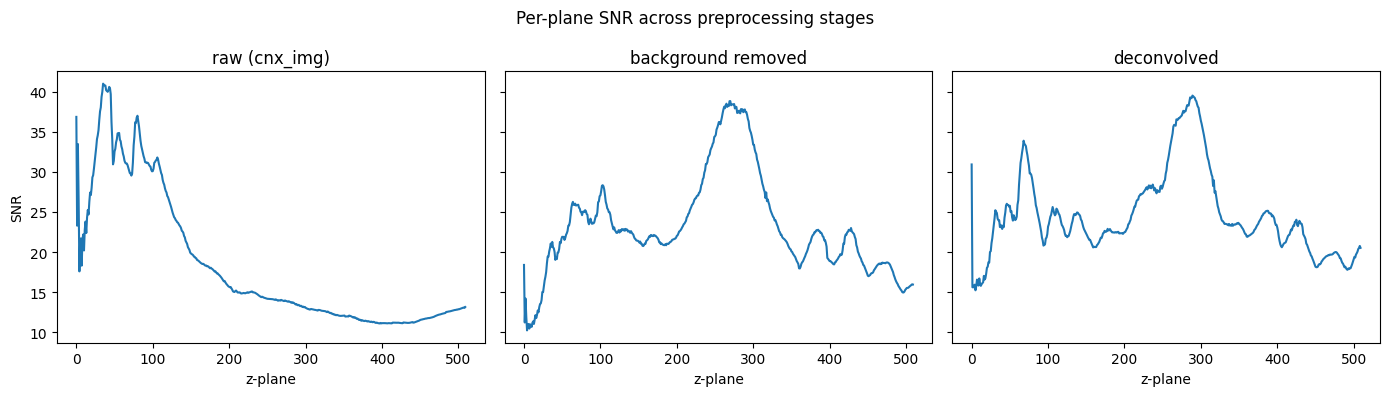

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# The three stages to compare
stages = {
    "raw (cnx_img)": cnx_img,
    "background removed": background_removed,
    "deconvolved": deconvolved,
}

# SNR per plane for each stage
snr = {name: np.array([compute_snr(vol[z]) for z in range(len(vol))])
       for name, vol in stages.items()}

# Plot side by side, shared y-axis so the heights are directly comparable
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, (name, values) in zip(axes, snr.items()):
    ax.plot(values, color="tab:blue")
    ax.set_title(name)
    ax.set_xlabel("z-plane")

axes[0].set_ylabel("SNR")
fig.suptitle("Per-plane SNR across preprocessing stages")
plt.tight_layout()
plt.show()

In [21]:
# 1. Tissue vs black padding: smooth, then Otsu-threshold the column shape.
signal_percentile=99
background_percentile=50
plane = background_removed[250]
smoothed = gaussian_filter(plane, sigma=8)
tissue = smoothed > threshold_otsu(smoothed)
tissue_values = plane[tissue]

# 2. Split the tissue into bright signal and dark background.
signal = tissue_values[tissue_values >= np.percentile(tissue_values, signal_percentile)]
background = tissue_values[tissue_values <= np.percentile(tissue_values, background_percentile)]

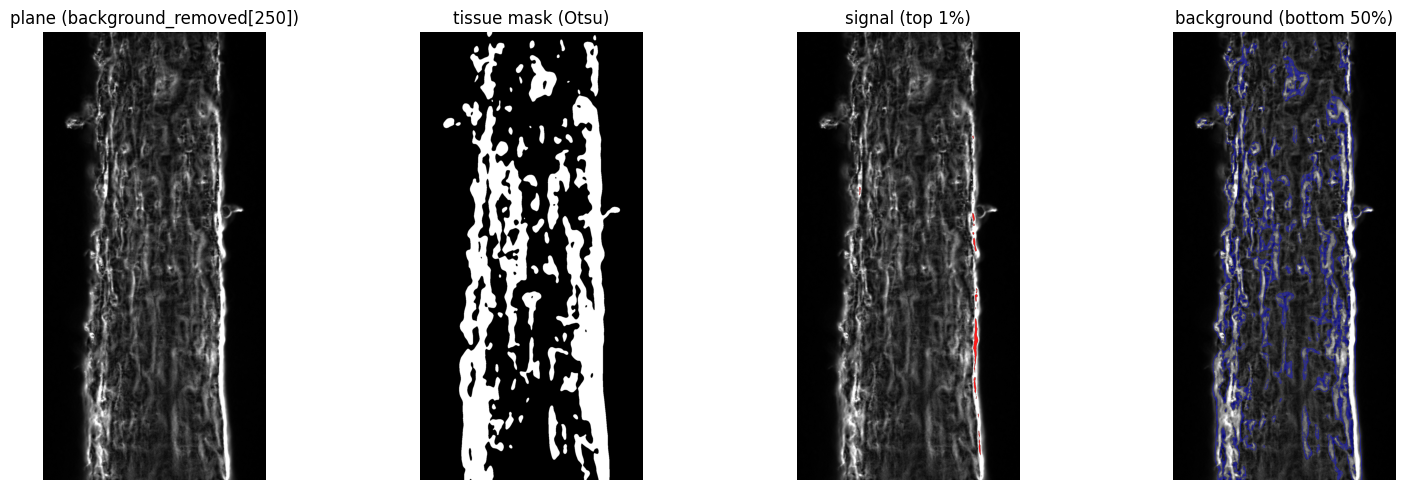

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from skimage.filters import threshold_otsu

signal_percentile = 99
background_percentile = 50
plane = np.asarray(background_removed[250], dtype=np.float64)

# 1. Tissue vs black padding
smoothed = gaussian_filter(plane, sigma=8)
tissue = smoothed > threshold_otsu(smoothed)
tissue_values = plane[tissue]

# 2. Rebuild the split as 2-D masks (same thresholds, but keeping positions)
signal_thresh = np.percentile(tissue_values, signal_percentile)
background_thresh = np.percentile(tissue_values, background_percentile)
signal_mask = tissue & (plane >= signal_thresh)
background_mask = tissue & (plane <= background_thresh)

# Display range for the grayscale (clip extremes so structure is visible)
vmin, vmax = np.percentile(plane, [1, 99])

fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(plane, cmap="gray", vmin=vmin, vmax=vmax)
axes[0].set_title("plane (background_removed[250])")

axes[1].imshow(tissue, cmap="gray")
axes[1].set_title("tissue mask (Otsu)")

# Signal pixels in red over the plane
axes[2].imshow(plane, cmap="gray", vmin=vmin, vmax=vmax)
axes[2].imshow(np.ma.masked_where(~signal_mask, signal_mask),
               cmap="autumn", alpha=0.9)
axes[2].set_title(f"signal (top {100 - signal_percentile}%)")

# Background pixels in blue over the plane
axes[3].imshow(plane, cmap="gray", vmin=vmin, vmax=vmax)
axes[3].imshow(np.ma.masked_where(~background_mask, background_mask),
               cmap="winter", alpha=0.4)
axes[3].set_title(f"background (bottom {background_percentile}%)")

for ax in axes:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Summary

This notebook reads and QCs the full-stack outputs from `1_1_preprocessing.ipynb`; it does not
recompute background removal or deconvolution.

- **Section 3** validates the loaded raw stack against the recorded `sample_plane_intensity`
  (whole-plane mean at the single `sample_plane` — a data-integrity check, not a signal measure).
- **Sections 5 and 7** report the **normalized foreground mean as mean ± SD across all planes
  in each zone's `z_start:z_end` range**: per-plane mean over the Otsu-thresholded foreground,
  with every stage scaled to its own 99.5th-percentile intensity. Aggregating over the zone
  range (rather than one plane) gives a more robust per-zone estimate with an error bar.

**Interpretation caveat:** because each stage is normalized to its own dynamic range, the
foreground means are comparable *across stages and zones* but are not absolute intensities.
Richardson-Lucy output in particular is not in the same physical units as the raw counts, so
only the normalized values should be compared — never the raw magnitudes.